### 04 - Introdução ao Scikit-Learn Supervisionado

**Objetivo**
Aprender o fluxo supervisionado com exemplos simples e visuais:
- **LinearRegression** para regressão
- **LogisticRegression** para classificação
- diferença entre desempenho de treino e teste
- noção de **underfitting** e **overfitting**

**Roadmap**
1. Conceito do zero: API de estimadores
2. Visualização dos dados sintéticos (antes da inspeção tabular)
3. Exemplo guiado: regressão linear
4. Exemplo guiado: regressão logística
5. Underfitting vs overfitting (linear vs árvore)
6. Diferenças entre classificadores
7. Erros comuns e checklist
        


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_regression, make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    root_mean_squared_error,
    r2_score,
    accuracy_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
np.random.seed(42)
sns.set_theme(style='whitegrid', context='notebook')
print('NumPy:', np.__version__)
print('pandas:', pd.__version__)


NumPy: 2.4.3
pandas: 3.0.1


### 1 - Conceito do Zero: API de estimadores

No scikit-learn, os modelos compartilham o mesmo contrato:
- **fit(X, y)**: aprende padrão
- **predict(X)**: gera previsão
- **score(X, y)**: métrica padrão do modelo

Isso permite trocar algoritmo sem mudar toda a estrutura do código.
        


In [2]:
X_demo, y_demo = make_regression(n_samples=120, n_features=3, noise=8.0, random_state=42)
modelo_demo = LinearRegression()

modelo_demo.fit(X_demo, y_demo)
print('Predições de exemplo:', np.round(modelo_demo.predict(X_demo[:5]), 2))
print('Score padrão (R2):', round(modelo_demo.score(X_demo, y_demo), 4))



Predições de exemplo: [  88.83 -187.66  -88.59   -0.86  135.16]
Score padrão (R2): 0.9954


### 2 - Visualização dos Dados Sintéticos (primeiro os gráficos)

Antes de olhar tabelas, vamos visualizar o formato dos dados.

- Regressão: um padrão aproximadamente linear com ruído.
- Classificação: duas classes com separação parcial.
        


In [3]:
X_reg, y_reg = make_regression(
    n_samples=220,
    n_features=1,
    n_informative=1,
    noise=20,
    random_state=42,
)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.30, random_state=42
)

In [4]:
X_clf, y_clf = make_classification(
    n_samples=500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.4,
    flip_y=0.03,
    random_state=42,
)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.25,
    random_state=42,
    stratify=y_clf,
)

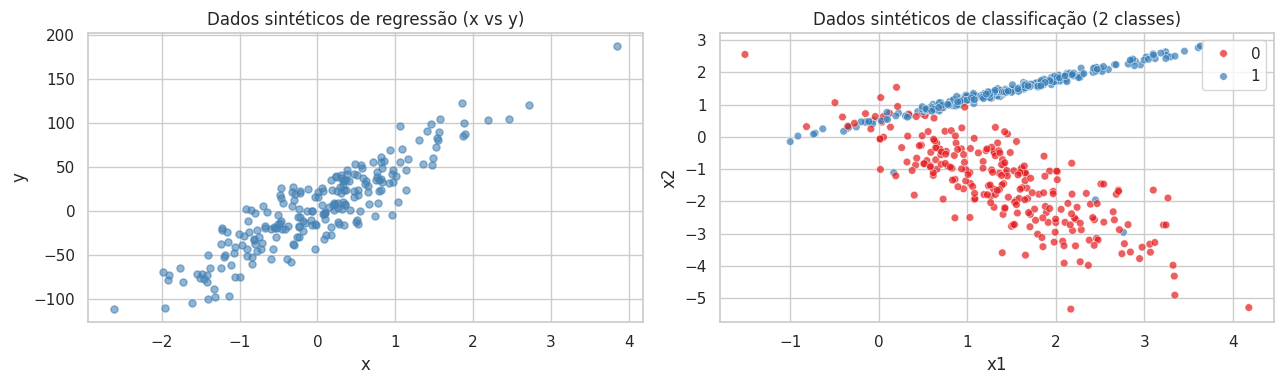

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(X_reg[:, 0], y_reg, alpha=0.6, s=26, color='steelblue')
axes[0].set_title('Dados sintéticos de regressão (x vs y)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

sns.scatterplot(
    x=X_clf[:, 0],
    y=X_clf[:, 1],
    hue=y_clf,
    palette='Set1',
    alpha=0.7,
    s=30,
    ax=axes[1],
    legend=True,
)
axes[1].set_title('Dados sintéticos de classificação (2 classes)')
axes[1].set_xlabel('x1')
axes[1].set_ylabel('x2')

plt.tight_layout()



Agora sim, depois de visualizar, vamos inspecionar amostras em formato tabular.
        


In [6]:
df_reg = pd.DataFrame({'x': X_reg[:, 0], 'y': y_reg})
df_clf = pd.DataFrame({'x1': X_clf[:, 0], 'x2': X_clf[:, 1], 'classe': y_clf})

print('Regressão - shape:', df_reg.shape)
print(df_reg.head())
print('\nClassificação - shape:', df_clf.shape)
print(df_clf.head())

Regressão - shape: (220, 2)
          x          y
0 -0.245388  -6.237436
1  0.714000  56.308625
2  0.821903  24.065059
3 -0.072829  -0.069137
4 -0.234587   2.418792

Classificação - shape: (500, 3)
         x1        x2  classe
0  1.427917  1.482279       1
1  1.806849 -1.778083       0
2  1.919133  1.756495       1
3  1.515604  1.485782       1
4  0.954900  1.062973       1


### 3 - Exemplo: Regressão Linear (**LinearRegression**)

**Ideia**: ajustar uma reta que minimize erro quadrático médio.

Métricas usadas:
- **RMSE**: erro médio na mesma escala de **y** (quanto menor, melhor)
- **R2**: proporção da variância explicada (quanto maior, melhor)
        


In [7]:
modelo_linear = LinearRegression()
modelo_linear.fit(X_train_reg, y_train_reg)

pred_train_lin = modelo_linear.predict(X_train_reg)
pred_test_lin = modelo_linear.predict(X_test_reg)

rmse_train_lin = root_mean_squared_error(y_train_reg, pred_train_lin)
rmse_test_lin = root_mean_squared_error(y_test_reg, pred_test_lin)
r2_train_lin = r2_score(y_train_reg, pred_train_lin)
r2_test_lin = r2_score(y_test_reg, pred_test_lin)

print(f'RMSE treino: {rmse_train_lin:.3f}')
print(f'RMSE teste:  {rmse_test_lin:.3f}')
print(f'R2 treino:   {r2_train_lin:.3f}')
print(f'R2 teste:    {r2_test_lin:.3f}')
print(f'Coeficiente angular: {modelo_linear.coef_[0]:.3f}')
print(f'Intercepto: {modelo_linear.intercept_:.3f}')



RMSE treino: 19.230
RMSE teste:  22.865
R2 treino:   0.847
R2 teste:    0.744
Coeficiente angular: 46.691
Intercepto: 3.419


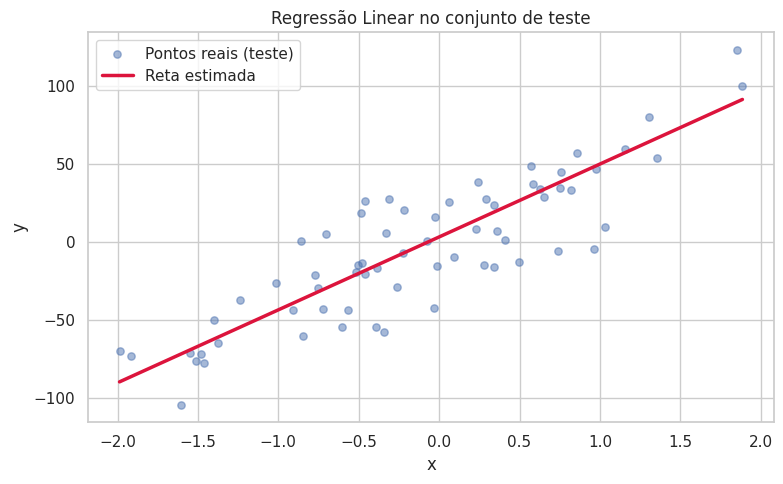

In [8]:
ordem = np.argsort(X_test_reg[:, 0])
X_plot = X_test_reg[ordem]
y_plot = y_test_reg[ordem]
pred_plot = modelo_linear.predict(X_plot)

plt.figure(figsize=(8, 5))
plt.scatter(X_test_reg[:, 0], y_test_reg, alpha=0.5, s=28, label='Pontos reais (teste)')
plt.plot(X_plot[:, 0], pred_plot, color='crimson', linewidth=2.5, label='Reta estimada')
plt.title('Regressão Linear no conjunto de teste')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()

**Leitura rápida**
- Se treino e teste ficam próximos, o modelo tende a generalizar bem.
- Se ambos os erros são altos, o modelo pode estar simples demais para o padrão real.

### 4 - Exemplo: Regressão Logística (**LogisticRegression**)

Apesar do nome "regressão", esse modelo é usado para **classificação**.

**Ideia**:
- calcula probabilidade de classe 1
- aplica um limiar (normalmente 0.5) para decidir classe final

Métricas usadas:
- **Accuracy**: proporção de acertos
- **F1**: equilíbrio entre precisão e recall
- **ROC-AUC**: qualidade de separação entre classes
        


In [9]:
modelo_logistico = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=500, random_state=42)),
])

modelo_logistico.fit(X_train_clf, y_train_clf)

pred_train_log = modelo_logistico.predict(X_train_clf)
pred_test_log = modelo_logistico.predict(X_test_clf)
score_test_log = modelo_logistico.predict_proba(X_test_clf)[:, 1]

print('Accuracy treino:', round(accuracy_score(y_train_clf, pred_train_log), 4))
print('Accuracy teste :', round(accuracy_score(y_test_clf, pred_test_log), 4))
print('F1 teste       :', round(f1_score(y_test_clf, pred_test_log), 4))
print('ROC-AUC teste  :', round(roc_auc_score(y_test_clf, score_test_log), 4))



Accuracy treino: 0.912
Accuracy teste : 0.944
F1 teste       : 0.9449
ROC-AUC teste  : 0.9908


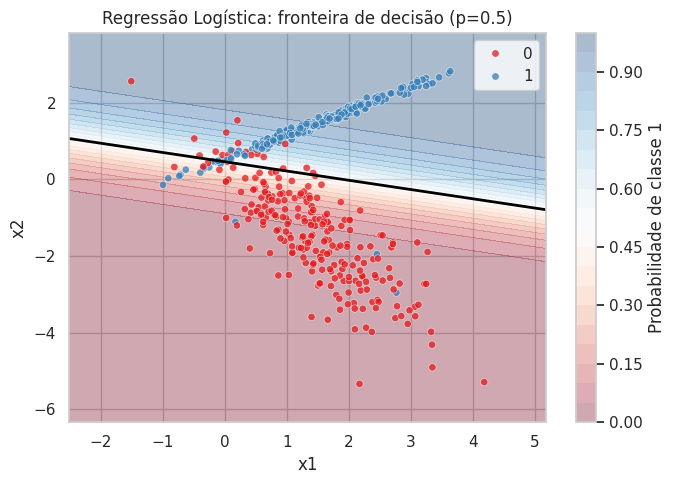

In [10]:
xx, yy = np.meshgrid(
    np.linspace(X_clf[:, 0].min() - 1, X_clf[:, 0].max() + 1, 200),
    np.linspace(X_clf[:, 1].min() - 1, X_clf[:, 1].max() + 1, 200),
)

grid = np.c_[xx.ravel(), yy.ravel()]
proba_grid = modelo_logistico.predict_proba(grid)[:, 1].reshape(xx.shape)

plt.figure(figsize=(7, 5))
cont = plt.contourf(xx, yy, proba_grid, levels=20, cmap='RdBu', alpha=0.35)
plt.colorbar(cont, label='Probabilidade de classe 1')

sns.scatterplot(x=X_clf[:, 0], y=X_clf[:, 1], hue=y_clf, palette='Set1', s=28, alpha=0.75, legend=True)
plt.contour(xx, yy, proba_grid, levels=[0.5], colors='black', linewidths=2)
plt.title('Regressão Logística: fronteira de decisão (p=0.5)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.tight_layout()

**Leitura rápida**
- A linha de contorno **p=0.5** é a fronteira de decisão do modelo.
- Pontos próximos dessa fronteira são mais incertos para classificar.

### 5 - Underfitting vs Overfitting (Regressão)

Agora vamos comparar:
- **LinearRegression**
- **DecisionTreeRegressor(max_depth=2)** (árvore rasa)
- **DecisionTreeRegressor()** (árvore profunda)

In [11]:
modelos_reg = {
    'LinearRegression': LinearRegression(),
    'Tree rasa': DecisionTreeRegressor(max_depth=3, random_state=42),
    'Tree profunda': DecisionTreeRegressor(random_state=42),
}

linhas = []
for nome, modelo in modelos_reg.items():
    modelo.fit(X_train_reg, y_train_reg)

    pred_train = modelo.predict(X_train_reg)
    pred_test = modelo.predict(X_test_reg)

    linhas.append({
        'modelo': nome,
        'RMSE treino': root_mean_squared_error(y_train_reg, pred_train),
        'RMSE teste': root_mean_squared_error(y_test_reg, pred_test),
        'R2 treino': r2_score(y_train_reg, pred_train),
        'R2 teste': r2_score(y_test_reg, pred_test),
    })

resultado_reg = pd.DataFrame(linhas).sort_values('RMSE teste').reset_index(drop=True)
resultado_reg



,modelo,RMSE treino,RMSE teste,R2 treino,R2 teste
0,LinearRegression,19.229968,22.865206,0.846884,0.743760
1,Tree rasa,17.800539,23.756055,0.868802,0.723404
2,Tree profunda,0.000000,29.099809,1.000000,0.584972


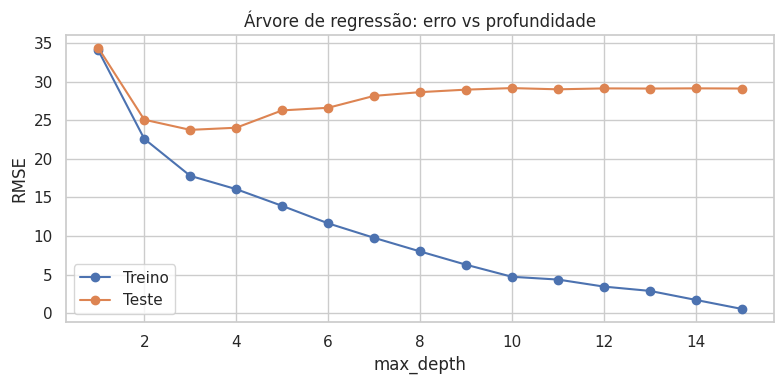

In [12]:
depths = range(1, 16)
curva = []

for d in depths:
    arvore = DecisionTreeRegressor(max_depth=d, random_state=42)
    arvore.fit(X_train_reg, y_train_reg)

    curva.append({
        'depth': d,
        'RMSE treino': root_mean_squared_error(y_train_reg, arvore.predict(X_train_reg)),
        'RMSE teste': root_mean_squared_error(y_test_reg, arvore.predict(X_test_reg)),
    })

curva_df = pd.DataFrame(curva)

plt.figure(figsize=(8, 4))
plt.plot(curva_df['depth'], curva_df['RMSE treino'], marker='o', label='Treino')
plt.plot(curva_df['depth'], curva_df['RMSE teste'], marker='o', label='Teste')
plt.title('Árvore de regressão: erro vs profundidade')
plt.xlabel('max_depth')
plt.ylabel('RMSE')
plt.legend()
plt.tight_layout()



**Interpretação (muito importante)**

- **Overfitting**: erro de treino muito baixo e erro de teste piorando.
  - No exemplo, isso aparece na **Tree profunda**.
- **Underfitting**: modelo rígido demais, com erro alto já no treino.
  - Em geral, aparece em modelos pouco flexíveis para padrões complexos.

Neste conjunto, a árvore profunda tende a "ganhar" no treino e perder no teste.

### 6 - Diferenças Entre Classificadores
Nesta etapa, vamos comparar 4 modelos com o **mesmo conjunto de teste**:
- **DummyClassifier** (baseline)
- **LogisticRegression**
- **DecisionTreeClassifier**
- **RandomForestClassifier**

A ideia não é procurar o melhor modelo absoluto, e sim entender:
- quem generaliza melhor (treino x teste)
- quem tem maior risco de overfitting
- como interpretar métricas em conjunto


In [13]:
modelos_clf = {
    'Dummy': DummyClassifier(strategy='most_frequent'),
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=400, random_state=42)),
    ]),
    'DecisionTree': DecisionTreeClassifier(max_depth=6, min_samples_leaf=4, random_state=42),
    'RandomForest': RandomForestClassifier(
        n_estimators=220,
        max_depth=10,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1,
    ),
}

rows = []
for nome, modelo in modelos_clf.items():
    modelo.fit(X_train_clf, y_train_clf)
    pred_train = modelo.predict(X_train_clf)
    pred_test = modelo.predict(X_test_clf)
    acc_train = accuracy_score(y_train_clf, pred_train)
    acc_test = accuracy_score(y_test_clf, pred_test)
    score_test = None
    if hasattr(modelo, 'predict_proba'):
        score_test = modelo.predict_proba(X_test_clf)[:, 1]
    rows.append({
        'modelo': nome,
        'Accuracy treino': acc_train,
        'Accuracy teste': acc_test,
        'Gap (treino - teste)': acc_train - acc_test,
        'F1 teste': f1_score(y_test_clf, pred_test, zero_division=0),
        'ROC-AUC teste': roc_auc_score(y_test_clf, score_test) if score_test is not None else np.nan,
    })
colunas = [
    'modelo',
    'Accuracy treino',
    'Accuracy teste',
    'Gap (treino - teste)',
    'F1 teste',
    'ROC-AUC teste',
]
resultado_clf = pd.DataFrame(rows)[colunas]
resultado_clf = resultado_clf.sort_values('ROC-AUC teste', ascending=False).reset_index(drop=True)
resultado_clf.round(4)


,modelo,Accuracy treino,Accuracy teste,Gap (treino - teste),F1 teste,ROC-AUC teste
0,RandomForest,0.9787,0.960,0.0187,0.9606,0.9928
1,LogisticRegression,0.9120,0.944,-0.0320,0.9449,0.9908
2,DecisionTree,0.9707,0.952,0.0187,0.9531,0.9720
3,Dummy,0.5040,0.504,0.0000,0.6702,0.5000


**Como interpretar essa tabela (exemplos práticos)**

1. **Dummy** é a régua mínima: se outro modelo não ganha dele, não está aprendendo padrão útil.
2. **Gap (treino - teste)** alto sugere **overfitting**.
   Exemplo: se no treino acerta quase tudo e no teste cai bastante, o modelo memorizou demais.
3. **F1** ajuda quando você quer equilíbrio entre precisão e recall.
4. **ROC-AUC** mede quão bem o modelo separa classes por score, independente de limiar fixo.

Exemplo de leitura típica:
- **LogisticRegression**: costuma ser estável, gap menor, ótima baseline.
- **DecisionTree**: pode ganhar no treino rápido, mas abrir gap no teste.
- **RandomForest**: tende a reduzir o gap da árvore única e melhorar generalização.


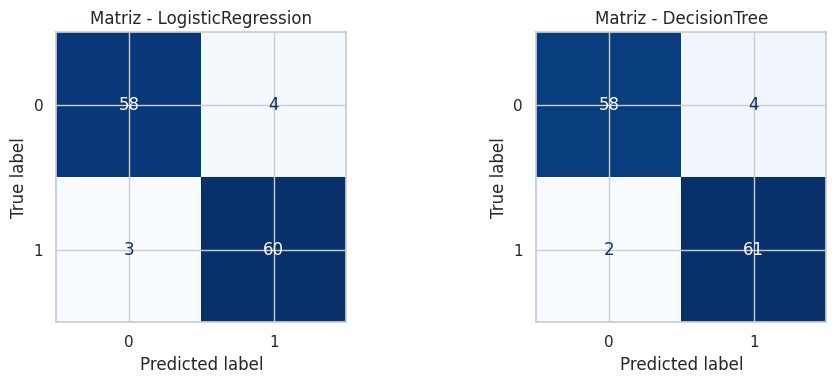

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, nome in zip(axes, ['LogisticRegression', 'DecisionTree']):
    ConfusionMatrixDisplay.from_estimator(
        modelos_clf[nome],
        X_test_clf,
        y_test_clf,
        cmap='Blues',
        colorbar=False,
        ax=ax,
    )
    ax.set_title(f'Matriz - {nome}')

plt.tight_layout()


**Resumo didático de escolha**

- Se você quer um ponto de partida simples e interpretável: comece com **LogisticRegression**.
- Se o padrão parece não linear e você aceita maior risco de overfitting: teste **DecisionTree**.
- Se vai usar dados tabuleres e quer pouco ajuste manual: **RandomForest** costuma ser um bom.

Dica prática: nunca escolha modelo olhando só uma métrica; compare **gap treino/teste + F1 + ROC-AUC**.

### 7 - Erros Comuns e Checklist

**Erros comuns**
- Focar só no score de treino.
- Ignorar baseline.
- Não visualizar os dados antes de modelar.
- Concluir por uma única métrica.

**Checklist**
1. Visualizou o padrão dos dados?
2. Separou treino/teste corretamente?
3. Comparou treino vs teste para detectar overfitting?
4. Comparou com baseline e com mais de uma métrica?
        
